# AC Stark Shift (Fig. 2e,f)

This notebook exports the AC Stark shift panels shown in Fig. 2e and Fig. 2f.

## Inputs (from `data/`)
- Frequency sweep (panel e)
  - `ACS_f_sweep_ACS_frequency_0408.csv` (drive frequency in GHz)
  - `ACS_f_sweep_Q1_delta_freq_array_0408.csv` (Q1 shift in Hz)
  - `ACS_f_sweep_Q2_delta_freq_array_0408.csv` (Q2 shift in Hz)
- Amplitude sweep (panel f)
  - `ACS_amp_sweep_Amp_1213_1035.csv` (drive amplitude in arbitrary units)
  - `ACS_amp_sweep_Q1_delta_freq_amp_array_1213_1035.csv` (Q1 shift in Hz)
  - `ACS_amp_sweep_Q2_delta_freq_amp_array_1213_1035.csv` (Q2 shift in Hz)

## Method summary
- **Panel e** fits a dispersive-model frequency shift for each qubit as a function of the drive frequency.
- **Panel f** plots the measured shift versus the drive amplitude and annotates a calibrated mapping from amplitude to Rabi rate (as used in the manuscript figure export).

## Outputs
- `main_text_figures/fig2ef_ac_stark_shift_sweeps.{png,pdf}`

```mermaid
flowchart LR
  in["`data/` CSVs\n(freq or amp sweeps)"] --> fit["Fit/prepare dispersive model\n(panel e)"]
  in --> plot["Assemble manuscript panels\n(panel e + panel f)"]
  fit --> plot --> out["Export PNG/PDF"]
```



In [21]:
import os
from pathlib import Path
from types import SimpleNamespace

# Ensure relative paths work regardless of where the notebook is launched.
_repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "data").exists() and (p / "notebooks").exists():
        _repo_root = p
        break
if _repo_root is not None:
    os.chdir(_repo_root)
print("Working directory:", Path.cwd())

# Qubit and drive-frequency constants used by the dispersive-model fit.
_local_data_dir = (Path.cwd() / "data").resolve()
_local_data_dir.mkdir(parents=True, exist_ok=True)
cf = SimpleNamespace(
    save_load_dir=str(_local_data_dir),
    Q1_freq=4167479308.0,
    Q1_ef_freq=4020563609.0,
    Q2_freq=4273982297.0,
    Q2_ef_freq=4129324029.0,
    ACS_freq=4176998162.0,
    config={},
)


def _as_abs_path(path_like):
    p = Path(path_like)
    if not p.is_absolute():
        p = Path.cwd() / p
    return p


def resolve_load_directory(path_like, experiment_name):
    candidates = []
    if path_like is not None and str(path_like).strip() != '':
        candidates.append(path_like)
    candidates.extend([Path.cwd() / 'data', Path.cwd() / 'data_analysis'])

    seen = set()
    for raw in candidates:
        try:
            p = _as_abs_path(raw)
        except Exception:
            continue
        key = str(p)
        if key in seen:
            continue
        seen.add(key)
        if p.exists() and any(p.glob(f'{experiment_name}_Q1_delta_freq_array_*.csv')):
            return p

    for raw in candidates:
        try:
            return _as_abs_path(raw)
        except Exception:
            continue
    return Path.cwd() / 'data'



Working directory: /Users/chellymac/projects/positronium-sensing


In [22]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Global Matplotlib style for consistent manuscript-quality exports.
lw = 1.0
mpl.rcParams['axes.linewidth'] = lw
mpl.rcParams['lines.linewidth'] = lw
mpl.rcParams['xtick.major.width'] = lw
mpl.rcParams['ytick.major.width'] = lw
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['legend.fontsize'] = 8
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'


## Load Data


In [23]:
import pandas as pd
from pathlib import Path

# Define the directory where files are saved
exp_name = 'ACS_f_sweep'
load_directory = resolve_load_directory(getattr(cf, 'save_load_dir', None), exp_name)

# Define the experiment name and preferred date suffix
preferred_date_suffix = '0408'

def _available_suffixes(directory, experiment_name):
    pattern = f'{experiment_name}_Q1_delta_freq_array_*.csv'
    suffixes = []
    for p in directory.glob(pattern):
        suffixes.append(p.stem.split('_')[-1])
    return sorted(set(suffixes))

suffixes = _available_suffixes(load_directory, exp_name)

if preferred_date_suffix in suffixes:
    date_suffix = preferred_date_suffix
elif 'date_suffix' in globals() and str(globals()['date_suffix']) in suffixes:
    date_suffix = str(globals()['date_suffix'])
elif suffixes:
    date_suffix = suffixes[-1]
else:
    raise FileNotFoundError(
        f'No ACS sweep CSV files found in {load_directory}. '
        'Run the save cell first or place the input CSV files in that directory.'
    )

# Construct the file paths
file_Q1_delta = load_directory / f'{exp_name}_Q1_delta_freq_array_{date_suffix}.csv'
file_Q2_delta = load_directory / f'{exp_name}_Q2_delta_freq_array_{date_suffix}.csv'
file_ACS_frequency = load_directory / f'{exp_name}_ACS_frequency_{date_suffix}.csv'
# Load the DataFrames from the CSV files
df_Q1_delta_loaded = pd.read_csv(file_Q1_delta)
df_Q2_delta_loaded = pd.read_csv(file_Q2_delta)
df_ACS_frequency_loaded = pd.read_csv(file_ACS_frequency)

# Amplitude-sweep inputs for panel f.
data_dir = Path('data')
file_amp = data_dir / 'ACS_amp_sweep_Amp_1213_1035.csv'
file_q_amp = data_dir / 'ACS_amp_sweep_Q1_delta_freq_amp_array_1213_1035.csv'
file_qbar_amp = data_dir / 'ACS_amp_sweep_Q2_delta_freq_amp_array_1213_1035.csv'

for fp in [file_amp, file_q_amp, file_qbar_amp]:
    if not fp.exists():
        raise FileNotFoundError(f'Missing input file: {fp}')

amp_arb = pd.read_csv(file_amp)['amp'].to_numpy(dtype=float)
delta_q_amp_hz = pd.read_csv(file_q_amp)['Q1_delta_freq'].to_numpy(dtype=float)
delta_qbar_amp_hz = pd.read_csv(file_qbar_amp)['Q2_delta_freq'].to_numpy(dtype=float)
omega_over_2pi_mhz_per_amp = 16.0
omega_s_over_2pi_mhz = omega_over_2pi_mhz_per_amp * amp_arb



## Fit Dispersive Model For Panel e

We fit a dispersive-model shift curve for each qubit. Using
$$\Delta = \omega_q - \omega_d,\qquad \alpha = \omega_{ef} - \omega_q,$$
the model used for the frequency shift is:

$$
\delta(\omega_d)=\frac{\alpha\,\mathrm{scale}}{2\,\Delta\,(\alpha+\Delta)}.
$$

We fit the single parameter `scale` using nonlinear least squares (`scipy.optimize.curve_fit`). For Q2 we refit on a restricted frequency range (`ACS_freq > 4.13 GHz`) to avoid the near-pole region dominating the fit.



In [24]:
from scipy.optimize import curve_fit

# Extract data as NumPy arrays
ACS_freq = df_ACS_frequency_loaded['ACS_frequency'].values * 1E9
Q1_delta_freq_array = df_Q1_delta_loaded['Q1_delta_freq'].values
Q2_delta_freq_array = df_Q2_delta_loaded['Q2_delta_freq'].values

def delta_Q_freq(ACS_freq, Q_freq, Q_ef_freq, scale_factor):
    #define anharmonicity
    alpha = Q_ef_freq - Q_freq
    delta_qs = Q_freq - ACS_freq
    delta_Q_freq = alpha * scale_factor / (2 * delta_qs * (alpha + delta_qs))
    return delta_Q_freq

scale_factor_Q1 = 1e13
scale_factor_Q2 = 1.5e13

# For Q1
popt_Q1, pcov_Q1 = curve_fit(
    lambda ACS_freq, scale_factor: delta_Q_freq(ACS_freq, cf.Q1_freq, cf.Q1_ef_freq, scale_factor),
    ACS_freq,
    Q1_delta_freq_array,
    p0=[scale_factor_Q1]
)
scale_factor_Q1 = popt_Q1[0]

# For Q2
popt_Q2, pcov_Q2 = curve_fit(
    lambda ACS_freq, scale_factor: delta_Q_freq(ACS_freq, cf.Q2_freq, cf.Q2_ef_freq, scale_factor),
    ACS_freq,
    Q2_delta_freq_array,
    p0=[scale_factor_Q2]
)
scale_factor_Q2 = popt_Q2[0]

# Filter the data for ACS_freq > 4.20E9
filter_condition = ACS_freq > 4.13E9
ACS_freq_filtered = ACS_freq[filter_condition]
Q2_delta_freq_filtered = Q2_delta_freq_array[filter_condition]

# For Q2, perform curve fitting over the filtered range
popt_Q2, pcov_Q2 = curve_fit(
    lambda ACS_freq, scale_factor: delta_Q_freq(ACS_freq, cf.Q2_freq, cf.Q2_ef_freq, scale_factor),
    ACS_freq_filtered,
    Q2_delta_freq_filtered,
    p0=[scale_factor_Q2]
)

# Extract the optimized scale factor for Q2
scale_factor_Q2 = popt_Q2[0]

# Build a dense frequency grid for plotting the fitted dispersive model.
freq_start = 4.0e9
freq_end = 4.4e9
freq_step = 0.1e6
ACS_freq_th = np.arange(freq_start, freq_end, freq_step)
delta_Q1_freq_th = delta_Q_freq(ACS_freq_th, cf.Q1_freq, cf.Q1_ef_freq, scale_factor_Q1)
delta_Q2_freq_th = delta_Q_freq(ACS_freq_th, cf.Q2_freq, cf.Q2_ef_freq, scale_factor_Q2*1.4)

# Figure-specific prep for panel e.
Q1_FREQ_HZ = cf.Q1_freq
Q2_FREQ_HZ = cf.Q2_freq
omega_q_ghz = Q1_FREQ_HZ * 1e-9
omega_qbar_ghz = Q2_FREQ_HZ * 1e-9

# Panel-f polynomial fits.
q_amp_mhz = delta_q_amp_hz * 1e-6
qbar_amp_mhz = delta_qbar_amp_hz * 1e-6
q_amp_poly = np.polyfit(omega_s_over_2pi_mhz, q_amp_mhz, deg=2)
qbar_amp_poly = np.polyfit(omega_s_over_2pi_mhz, qbar_amp_mhz, deg=2)
omega_dense = np.linspace(0, max(omega_s_over_2pi_mhz) + 0.2, 500)



## Plot Panels e and f


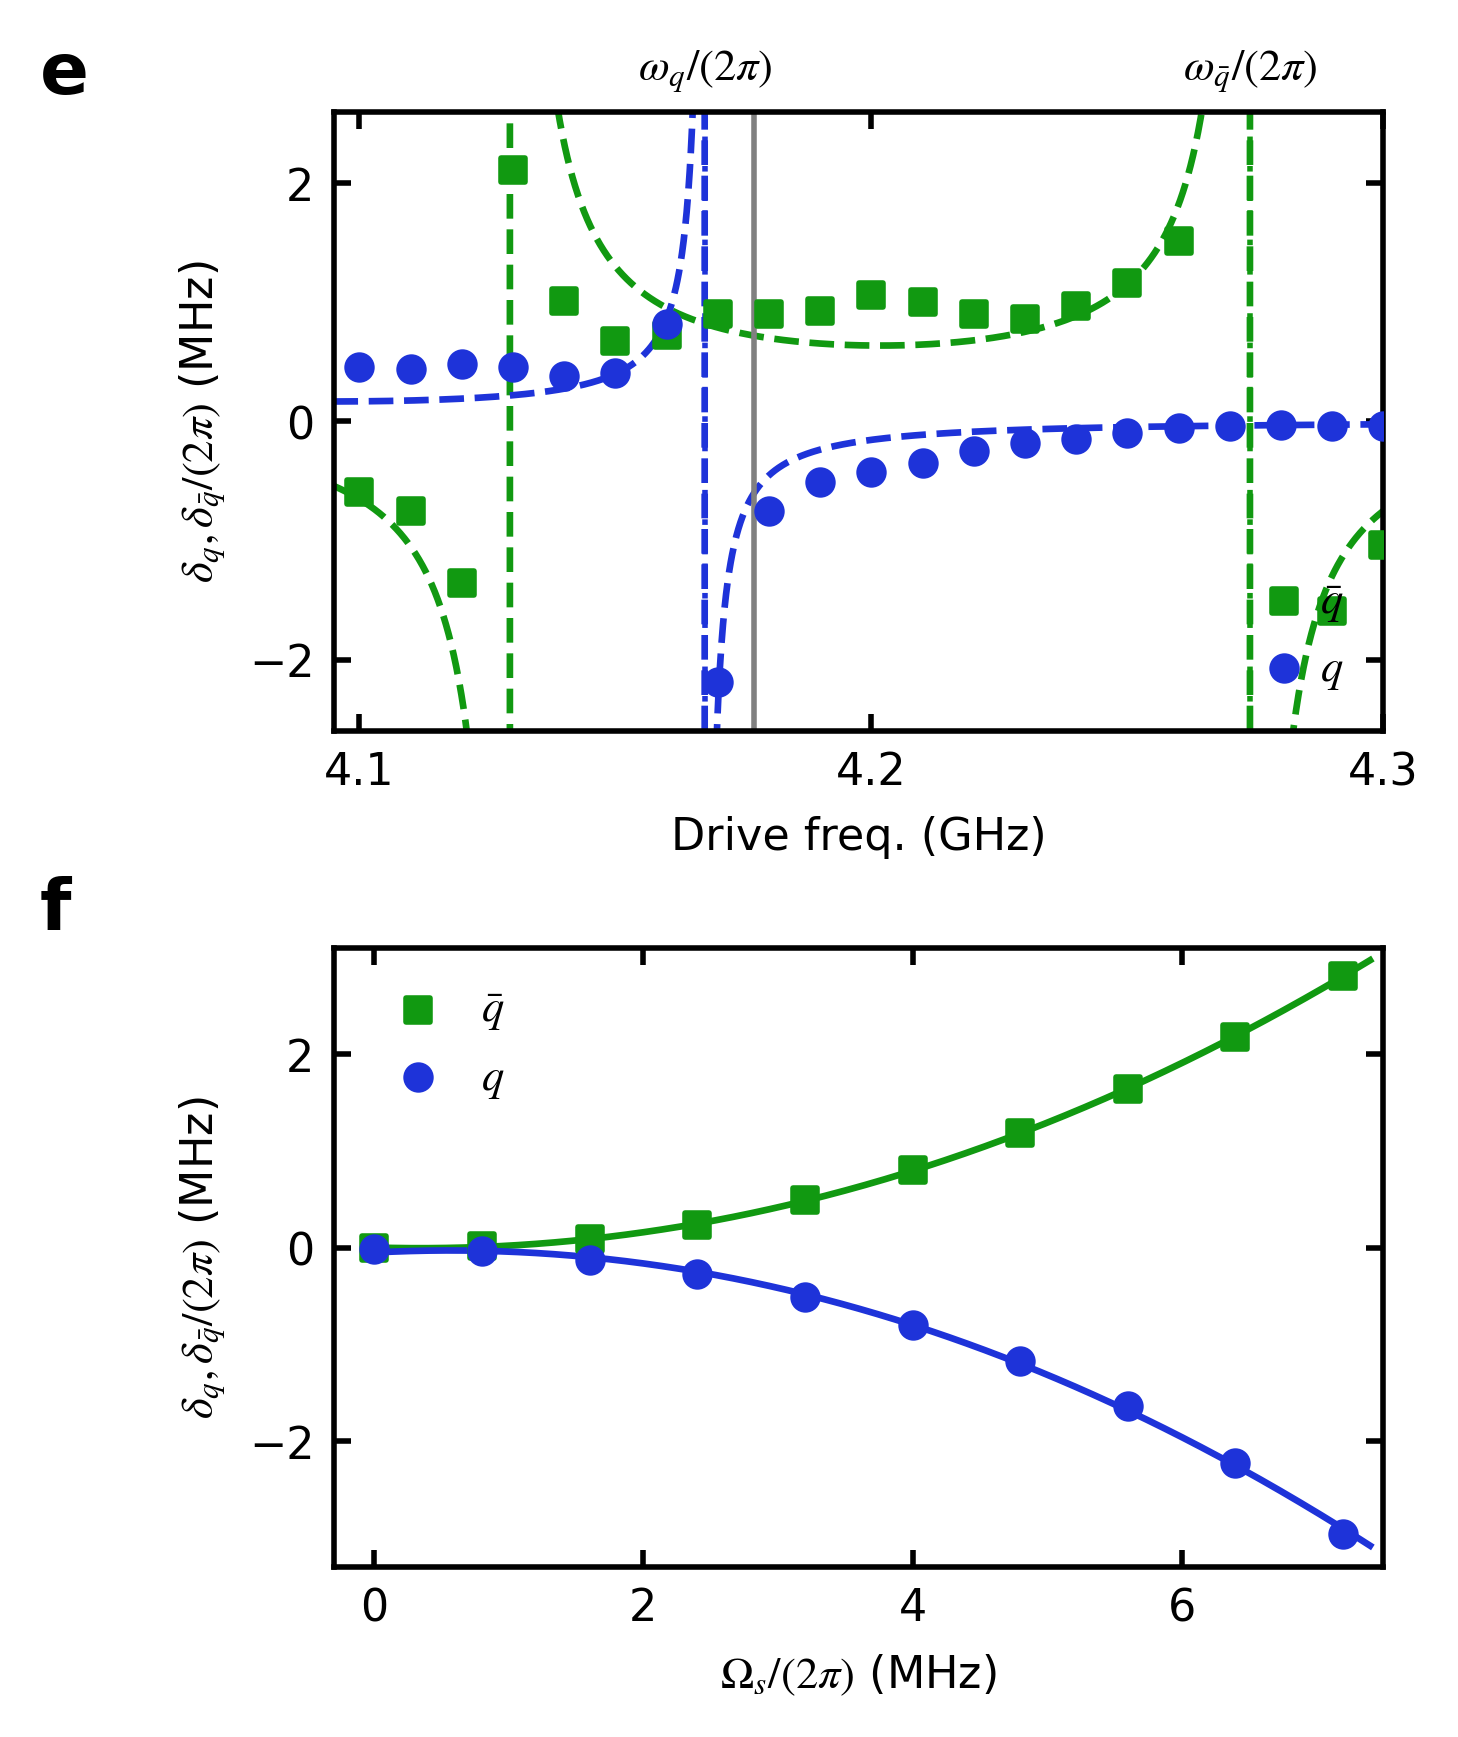

Saved: main_text_figures/fig2ef_ac_stark_shift_sweeps.png
Saved: main_text_figures/fig2ef_ac_stark_shift_sweeps.pdf

Panel-e fit summary
Q1 scale_factor / 1e13 = 1.229010
Q2 scale_factor / 1e13 = 3.290526
Q1 omega_q/(2pi) = 4.167479 GHz
Q2 omega_q/(2pi) = 4.273982 GHz


In [25]:
green = '#119911'
blue = '#1E33D9'
panel_bg = 'white'

fig_size = np.asarray([8.6, 12.0]) / 2.54
fig = plt.figure(figsize=fig_size, dpi=400)
fig.patch.set_facecolor('white')
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0], hspace=0.35)

# ----------------------------- Panel e -----------------------------
ax_e = fig.add_subplot(gs[0, 0])
ax_e.set_facecolor(panel_bg)

ax_e.plot(ACS_freq_th * 1e-9, delta_Q2_freq_th * 1e-6, '--', color=green, linewidth=1.2)
ax_e.plot(ACS_freq_th * 1e-9, delta_Q1_freq_th * 1e-6, '--', color=blue, linewidth=1.2)

ax_e.scatter(
    ACS_freq * 1e-9,
    Q2_delta_freq_array * 1e-6,
    s=18,
    marker='s',
    color=green,
    label=r'$\bar{q}$',
    zorder=3,
)
ax_e.scatter(
    ACS_freq * 1e-9,
    Q1_delta_freq_array * 1e-6,
    s=20,
    marker='o',
    color=blue,
    label=r'$q$',
    zorder=3,
)

# Pole markers.
ax_e.axvline(omega_q_ghz, color=blue, linestyle=':', linewidth=1.0)
ax_e.axvline(omega_qbar_ghz, color=green, linestyle=':', linewidth=1.0)

# Requested reference line at fixed drive frequency.
ax_e.axvline(4.177, color='gray', linestyle='-', linewidth=1.0)

ax_e.text(
    omega_q_ghz,
    1.03,
    r'$\omega_q/(2\pi)$',
    ha='center',
    va='bottom',
    transform=ax_e.get_xaxis_transform(),
)
ax_e.text(
    omega_qbar_ghz,
    1.03,
    r'$\omega_{\bar{q}}/(2\pi)$',
    ha='center',
    va='bottom',
    transform=ax_e.get_xaxis_transform(),
)

ax_e.set_xlim(4.095, 4.30)
ax_e.set_ylim(-2.6, 2.6)
ax_e.set_xticks([4.10, 4.20, 4.30])
ax_e.set_yticks([-2, 0, 2])
ax_e.tick_params(direction='in', top=True, right=True)
ax_e.set_xlabel('Drive freq. (GHz)')
ax_e.set_ylabel(r'$\delta_q,\delta_{\bar q}/(2\pi)$ (MHz)')
ax_e.legend(loc='lower right', frameon=False, handlelength=1.0, handletextpad=0.3)
ax_e.text(-0.28, 1.03, 'e', transform=ax_e.transAxes, fontsize=13, fontweight='bold')

# ----------------------------- Panel f -----------------------------
ax_f = fig.add_subplot(gs[1, 0])
ax_f.set_facecolor(panel_bg)

ax_f.plot(omega_dense, np.polyval(qbar_amp_poly, omega_dense), color=green, linewidth=1.2)
ax_f.plot(omega_dense, np.polyval(q_amp_poly, omega_dense), color=blue, linewidth=1.2)

ax_f.scatter(
    omega_s_over_2pi_mhz,
    qbar_amp_mhz,
    s=18,
    marker='s',
    color=green,
    label=r'$\bar{q}$',
    zorder=3,
)
ax_f.scatter(
    omega_s_over_2pi_mhz,
    q_amp_mhz,
    s=20,
    marker='o',
    color=blue,
    label=r'$q$',
    zorder=3,
)

ax_f.set_xlim(-0.3, 7.5)
ax_f.set_ylim(-3.3, 3.1)
ax_f.set_xticks([0, 2, 4, 6])
ax_f.set_yticks([-2, 0, 2])
ax_f.tick_params(direction='in', top=True, right=True)
ax_f.set_xlabel(r'$\Omega_s/(2\pi)$ (MHz)')
ax_f.set_ylabel(r'$\delta_q,\delta_{\bar q}/(2\pi)$ (MHz)')
ax_f.legend(loc='upper left', frameon=False, handlelength=2.0, handletextpad=0.4)
ax_f.text(-0.28, 1.03, 'f', transform=ax_f.transAxes, fontsize=13, fontweight='bold')

# Save outputs.
out_png = Path('main_text_figures') / 'fig2ef_ac_stark_shift_sweeps.png'
out_pdf = Path('main_text_figures') / 'fig2ef_ac_stark_shift_sweeps.pdf'
out_png.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(out_png, bbox_inches='tight', facecolor='white')
fig.savefig(out_pdf, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")
print()
print("Panel-e fit summary")
print(f"Q1 scale_factor / 1e13 = {scale_factor_Q1 / 1e13:.6f}")
print(f"Q2 scale_factor / 1e13 = {scale_factor_Q2 / 1e13:.6f}")
print(f"Q1 omega_q/(2pi) = {omega_q_ghz:.6f} GHz")
print(f"Q2 omega_q/(2pi) = {omega_qbar_ghz:.6f} GHz")

